# Ploting Spatial Data

## Lesson 1: Customizing Maps in Python with Matplotlib

When making maps, we often want to create legends, customize colors, adjust zoom levels, or even make interactive maps.

Learn how to customize maps created using vector data in Python with matplotlib, geopandas, and folium.

In [1]:
import earthpy as et

# get the data
# et.data.get_data("spatial-vector-lidar")  # uncomment only in case of new download

/home/marcos/.pyenv/versions/3.12.9/envs/aluno/lib/python3.12/site-packages/earthpy/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string


Extracted output to /home/marcos/earth-analytics/data/spatial-vector-lidar/.


'/home/marcos/earth-analytics/data/spatial-vector-lidar/.'

### Create Custom Maps with Python

In this lesson we will learn how to customize map symbology or the colors and symbols used to represent `vector data` in Python.

There are many different ways to create maps in Python, in this lesson we will use the `geopandas` and `matplotlib`.

In [1]:
# import libraries
import os

import earthpy as et
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import box

# set working dir
os.chdir(os.path.join(et.io.HOME, "aluno", "python", "earth-analytics", "data"))

/home/marcos/.pyenv/versions/3.12.9/envs/aluno/lib/python3.12/site-packages/earthpy/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string


In [2]:
# import shapefile
sjer_roads_path = os.path.join("spatial-vector-lidar", "california", "madera-county-roads", "tl_2013_06039_roads.shp")
sjer_roads = gpd.read_file(sjer_roads_path)

# view data type
sjer_roads

,LINEARID,FULLNAME,RTTYP,MTFCC,geometry
0,110454239066,N 14th St,M,S1400,"LINESTRING (-120.27227 37.11615, -120.27244 37..."
1,110454239052,N 11th St,M,S1400,"LINESTRING (-120.26788 37.11667, -120.26807 37..."
2,110454239056,N 12th St,M,S1400,"LINESTRING (-120.27053 37.11749, -120.27045 37..."
3,110454239047,N 10th St,M,S1400,"LINESTRING (-120.26703 37.11735, -120.26721 37..."
4,110454243091,N Westberry Blvd,M,S1400,"LINESTRING (-120.10122 36.96524, -120.10123 36..."
...,...,...,...,...,...
9635,110454244324,Kings Canyon Ct N,M,S1400,"LINESTRING (-119.77493 37.18221, -119.7748 37...."
9636,110454242718,Gold Dust Ct N,M,S1400,"LINESTRING (-119.71746 37.23623, -119.71739 37..."
9637,110454243105,Whitworth Dr N,M,S1400,"LINESTRING (-120.08446 37.01512, -120.0844 37...."
9638,110454241750,Cascadel Dr N,M,S1400,"LINESTRING (-119.4574 37.22955, -119.45721 37...."


In [6]:
sjer_roads
print(sjer_roads['RTTYP'].unique())

['M' None 'S' 'C']


### Replacing missing data values

It looks like we have some missing values in our road types. We want to plot all road types even those that are set to `None`. Change the roads with an **RTTYP** attribute of `None` to "unknown".

In [3]:
# map each value to a new value
sjer_roads['RTTYP'] = sjer_roads['RTTYP'].replace(np.nan, 'Unknown')

print(sjer_roads['RTTYP'].unique())

['M' 'Unknown' 'S' 'C']


### Creating a map with geopandas and matplotlib

If we plot our data using the standard geopandas `.plot`, geopandas will select colors four our lines. We can add a legend using the `legend=True` argument, houever notice that the legend is composed of **circles** representing each line type rather than **a line**. We also don't have full control over what color is applied to which line, line width and other symbology attributes.

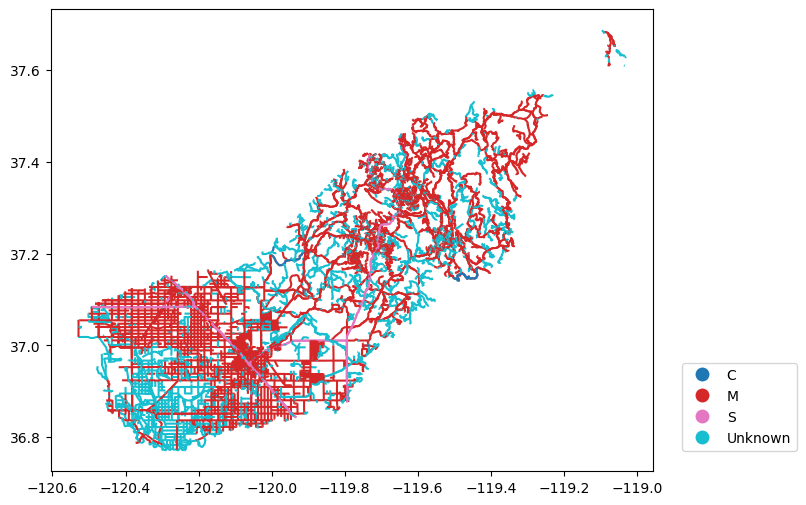

In [15]:
# define plot space
fig, ax = plt.subplots(figsize=(14, 6))

# add data to the plot using geopandas function plot on layer
sjer_roads.plot(column="RTTYP", categorical=True, legend=True, ax=ax)

# adjust legend location
leg = ax.get_legend()
leg.set_bbox_to_anchor((1.25, 0.25))

plt.show()

### Plot color by attribute

To plot a vector layer by attribyte value so that each road type is colored accoirding to it's respective value, and so the legend also represents that same symbology we need to do three things:
1. create a dictionary that associeates a particular color with a particular attribute value
2. loop through the data and apply that color to each value
3. add a **label** argument to the plot so we can call `ax.legend()` to make the final legend

In [4]:
# create a dictionary associating attribute and color
road_colors = {
    "M": 'sienna',
    "S": 'red',
    "C": 'purple',
    "Unknown": 'grey'
}
road_colors

{'M': 'sienna', 'S': 'red', 'C': 'purple', 'Unknown': 'grey'}

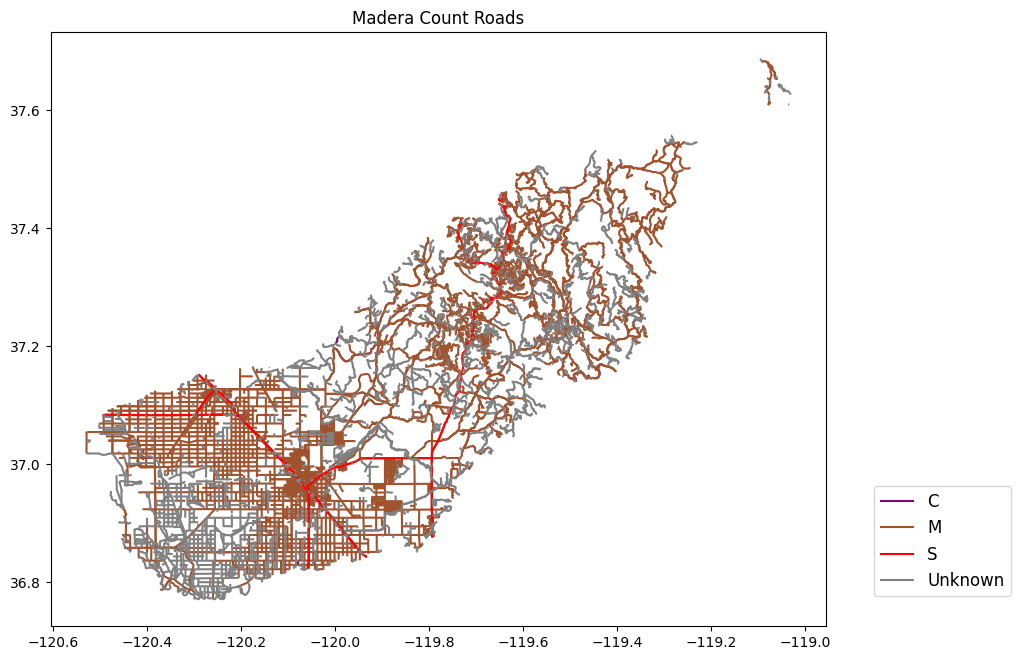

In [5]:
# redoing the map with a loop

# define fig space
fig, ax = plt.subplots(figsize=(10, 10))

# looping through the data grouping it by type in order to reduce the size
for road_type, data in sjer_roads.groupby("RTTYP"):
    # define the color for each group
    color = road_colors[road_type]

    # plot each group using the color
    data.plot(color=color, ax=ax, label=road_type)

# adjusting the legend
ax.legend(bbox_to_anchor=(1.25, 0.25), prop={"size": 12})
ax.set(title="Madera Count Roads")

plt.show()

### Adjusting the line width

We can adjust the width of the lines using `linewidth=` parameter. The best way to do this is create a dictionay with the widths for each type of road.

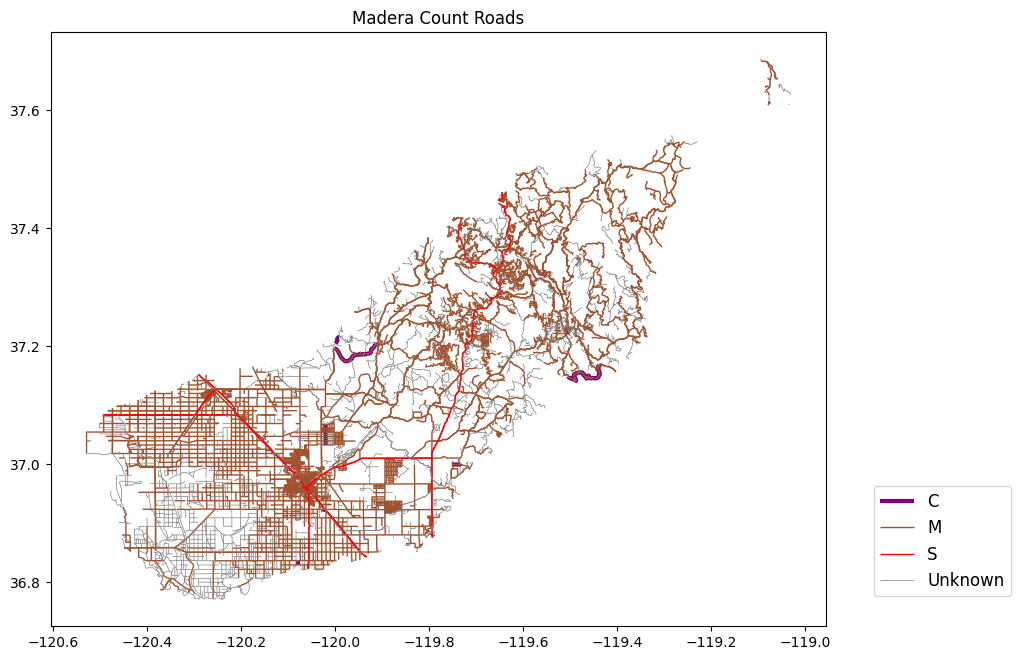

In [6]:
## line width for each type of road
line_widths = {
    "M": 1,
    "S": 1,
    "C": 3,
    "Unknown": 0.5
}

# define the plot space
fig, ax = plt.subplots(figsize=(10, 10))

# loop through the data grouping it
for road_type, data in sjer_roads.groupby("RTTYP"):
    color = road_colors[road_type]
    # add data and setting line width with line_widths[road_type]
    data.plot(color=color, ax=ax, label=road_type, linewidth=line_widths[road_type])

# adding the legend and adjust position
ax.legend(bbox_to_anchor=(1.25, 0.25), prop={"size": 12})

# define the title
ax.set(title="Madera Count Roads")

plt.show()

### Adding a Point Shapefile to the map

We can add another layer to the map to create a more complex map with a legend that represents both layers.

In [8]:
# importing the layer
sjer_samples_path = os.path.join("spatial-vector-lidar", "california", "neon-sjer-site", "vector_data", "SJER_plot_centroids.shp")
sjer_samples = gpd.read_file(sjer_samples_path)

sjer_samples.head(5)

,Plot_ID,Point,northing,easting,plot_type,geometry
0,SJER1068,center,4111567.818,255852.376,trees,POINT (255852.376 4111567.818)
1,SJER112,center,4111298.971,257406.967,trees,POINT (257406.967 4111298.971)
2,SJER116,center,4110819.876,256838.760,grass,POINT (256838.76 4110819.876)
3,SJER117,center,4108752.026,256176.947,trees,POINT (256176.947 4108752.026)
4,SJER120,center,4110476.079,255968.372,grass,POINT (255968.372 4110476.079)


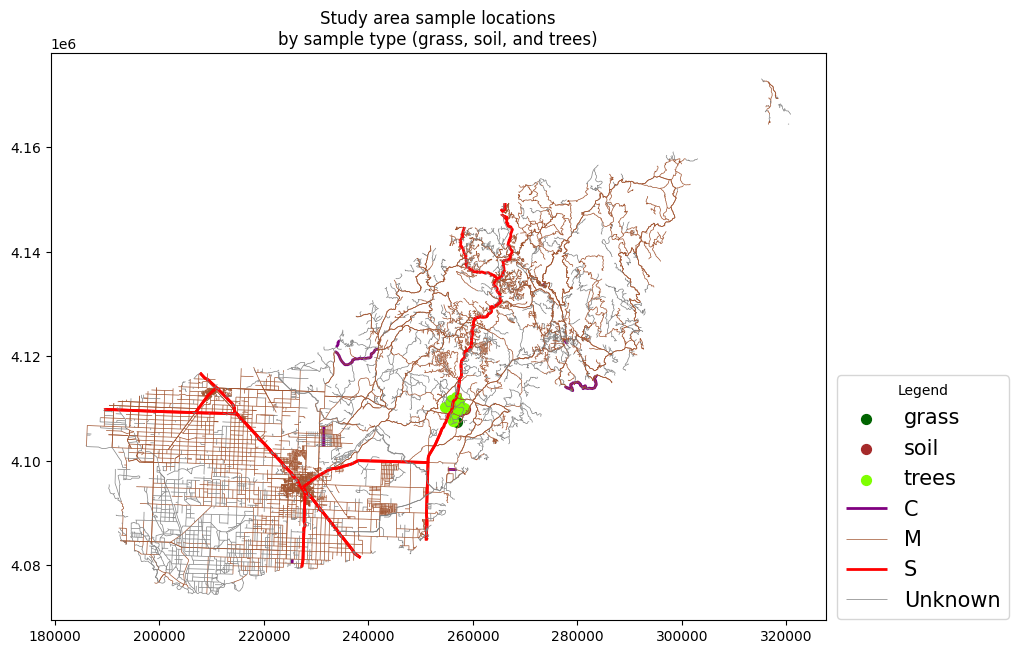

In [18]:
# color for land cover survey
sample_colors = {
    "trees": "chartreuse",
    "grass": "darkgreen",
    "soil": "brown"
}

# width for lines
line_widths = {"M": 0.5, "S": 2, "C": 2, "Unknown": 0.5}

# reproject roads to the same projection as the survey layer
sjer_roads_utm = sjer_roads.to_crs(sjer_samples.crs)

# define the fig space
fig, ax = plt.subplots(figsize=(10, 10))

# add survey data
for sample, data in sjer_samples.groupby("plot_type"):
    data.plot(color=sample_colors[sample], ax=ax, label=sample, markersize=50)

# add roads data
for road_type, data in sjer_roads_utm.groupby("RTTYP"):
    data.plot(color=road_colors[road_type], ax=ax, linewidth=line_widths[road_type], label=road_type)

# set title
ax.set(title="Study area sample locations\nby sample type (grass, soil, and trees)")

# adjust legend
ax.legend(fontsize=15, frameon=True, bbox_to_anchor=(1.25, 0.45), title="Legend")

plt.show()



## Lesson 3. Customize Map Extents

### Change the Spatial Extent of a Plot

Sometimes we modify our data by clipping it to a specified boundary. This is useful when we want to:
1. Make our data smaller to speed up processing and reduce file size
2. Make analysis simpler and faster given less data to work with

However, if we just want to plot the data, you can consider adjusting the spatial extent of a plot to "zoom in".

To zoom in on a region of our plot, we first need to grad the spatial extent of the object.

In [26]:
sjer_aoi_path = os.path.join("spatial-vector-lidar", "california", "neon-sjer-site", "vector_data", "SJER_crop.shp")
sjer_aoi = gpd.read_file(sjer_aoi_path)
sjer_aoi

,Id,geometry
0,0,"POLYGON ((254570.567 4112361.92, 258867.409 41..."


In [25]:
country_boundary_path = os.path.join("spatial-vector-lidar", "usa", "usa-boundary-dissolved.shp")
country_boundary = gpd.read_file(country_boundary_path)
country_boundary

,NAME,geometry
0,United States,"MULTIPOLYGON Z (((-118.59397 33.4672 0, -118.4..."


In [23]:
ne_roads_path = os.path.join("spatial-vector-lidar", "global", "ne_10m_roads", "ne_10m_n_america_roads.shp")
ne_roads = gpd.read_file(ne_roads_path)
ne_roads.head(5)

,scalerank,featurecla,type,sov_a3,note,edited,name,namealt,namealtt,routeraw,...,rwdb_rd_id,orig_fid,prefix,uident,continent,expressway,level,min_zoom,min_label,geometry
0,8,Road,Secondary Highway,CAN,None,"Version 1.5: Changed alignment, a few adds in ...",None,None,None,None,...,0,0,None,314705,North America,0,None,7.1,9.6,"LINESTRING (-133.32533 62.21571, -133.31664 62..."
1,8,Road,Secondary Highway,USA,None,New in version 2.0.0,13,None,None,None,...,0,576,US,7241,North America,0,Federal,7.1,9.6,"LINESTRING (-75.64398 39.61859, -75.61857 39.6..."
2,7,Road,Secondary Highway,USA,None,"Version 1.5: Changed alignment, a few adds in ...",83,None,None,None,...,0,0,None,108105,North America,0,Federal,7.0,8.6,"LINESTRING (-100.50543 42.80753, -100.53495 42..."
3,8,Road,Secondary Highway,USA,None,New in version 2.0.0,202,None,None,None,...,0,577,US,7243,North America,0,Federal,7.1,9.6,"LINESTRING (-75.54232 39.7666, -75.54979 39.81..."
4,7,Road,Secondary Highway,USA,None,"Version 1.5: Changed alignment, a few adds in ...",840,None,None,None,...,0,0,None,0,North America,0,U/C,7.0,9.5,"LINESTRING (-87.27432 36.02439, -87.22916 35.9..."


In [27]:
# get spatial extent - to zoom in on the map rather than clipping
aoi_bounds = sjer_aoi.geometry.total_bounds
aoi_bounds

array([ 254570.567     , 4107303.07684455,  258867.40933092,
       4112361.92026107])

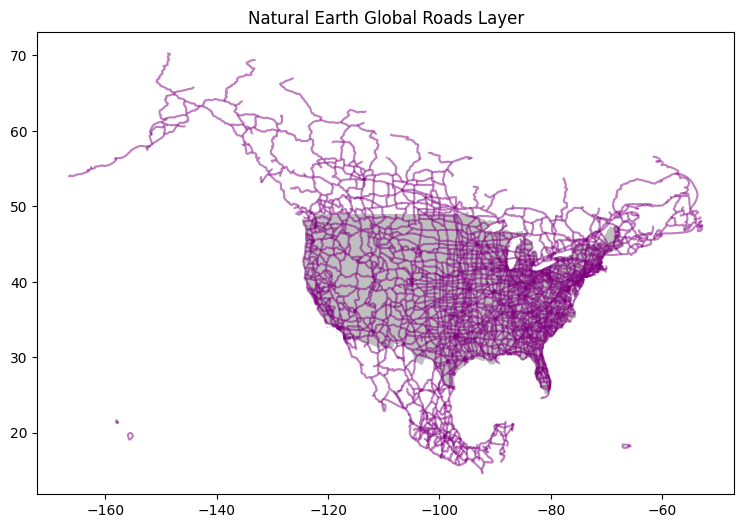

In [38]:
# a map without extent zoom in

# figure space
fig, ax = plt.subplots(figsize=(14, 6))

# create the plot and set it to ax
country_boundary.plot(alpha=0.5, ax=ax, color='grey')
ne_roads.plot(color='purple', ax=ax, alpha=0.5)

# set title and
ax.set(title="Natural Earth Global Roads Layer")

#plt.axis("equal")  # same size for both axis

plt.show()

We can set the **x** and **y** limits of the map using the x an y min and max values from the bounds object.

`country_boundary.total_bounds`

Notice in the plot bellow, we can still see roads that fall outside of the US boundary area but are within the rectangular spatial extent of the boundary layer.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


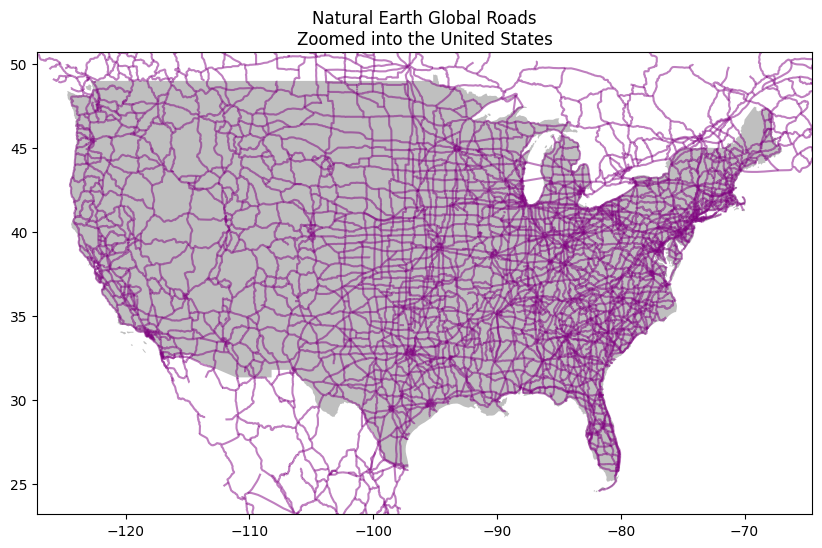

In [36]:
# plot the data with a modified spatial extent

# define the figure space
fig, ax = plt.subplots(figsize=(10, 6))

# get the extent
xlim = ([country_boundary.total_bounds[0], country_boundary.total_bounds[2]])
ylim = ([country_boundary.total_bounds[1], country_boundary.total_bounds[3]])

ax.set_xlim(xlim)
ax.set_ylim(ylim)

# add data to the plot
country_boundary.plot(alpha=0.5, ax=ax, color='grey')
ne_roads.plot(color='purple', ax=ax, alpha=0.5)

# set title
ax.set(title="Natural Earth Global Roads\nZoomed into the United States")


plt.show()

In [ ]:
#

In [ ]:
#